In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, average_precision_score, 
                             confusion_matrix)

import warnings
warnings.filterwarnings('ignore')

print("Библиотеки для Baseline загружены!")

Библиотеки для Baseline загружены!


In [4]:
# Загружаем данные из папки processed
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze() # squeeze превращает DataFrame в Series (вектор)

X_val = pd.read_csv('../data/processed/X_val.csv')
y_val = pd.read_csv('../data/processed/y_val.csv').squeeze()

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Размеры выборок:")
print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Val:   X={X_val.shape}, y={y_val.shape}")

Размеры выборок:
Train: X=(240090, 15), y=(240090,)
Val:   X=(60023, 15), y=(60023,)


In [5]:
# 1. Кодирование категориальных (строковых) признаков
# drop_first=True спасает от мультиколлинеарности
X_train_encoded = pd.get_dummies(X_train, drop_first=True)

# Чтобы колонки в Val и Test точно совпадали с Train (на случай, если в Val нет какой-то категории)
X_val_encoded = pd.get_dummies(X_val, drop_first=True).reindex(columns=X_train_encoded.columns, fill_value=0)
X_test_encoded = pd.get_dummies(X_test, drop_first=True).reindex(columns=X_train_encoded.columns, fill_value=0)

# 2. Масштабирование признаков (StandardScaler)
# Линейные модели очень чувствительны к разному масштабу данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("Категориальные признаки закодированы. Данные отмасштабированы (StandardScaler).")

Категориальные признаки закодированы. Данные отмасштабированы (StandardScaler).


In [6]:
# Инициализируем модель Логистической регрессии
baseline_model = LogisticRegression(
    random_state=42, 
    max_iter=1000, 
    class_weight='balanced' # Ключевой параметр при дисбалансе 1.6% !
)

# Обучаем
print("Обучение Логистической регрессии (Baseline)...")
baseline_model.fit(X_train_scaled, y_train)
print("Модель успешно обучена!")

Обучение Логистической регрессии (Baseline)...
Модель успешно обучена!


--- Результаты на выборке: Validation Set ---
Accuracy:  0.7973
Precision: 0.0682 (Доля настоящих мошенников среди тех, кого мы назвали мошенниками)
Recall:    0.7585 (Сколько всего мошенников мы смогли поймать)
F1-score:  0.1251
ROC-AUC:   0.8428
PR-AUC:    0.3316 <- ГЛАВНАЯ МЕТРИКА



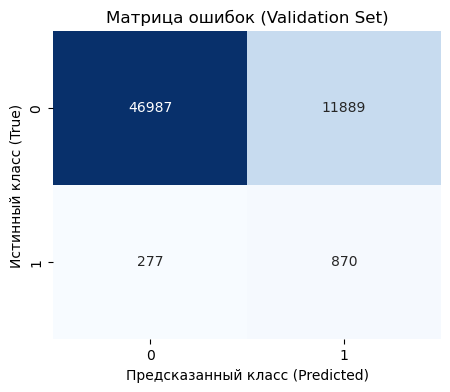

In [7]:
# Функция для красивого вывода метрик и матрицы ошибок
def evaluate_model(model, X, y, dataset_name="Validation"):
    # Предсказываем классы (0 или 1) и вероятности
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    
    print(f"--- Результаты на выборке: {dataset_name} ---")
    # Базовые метрики
    print(f"Accuracy:  {accuracy_score(y, y_pred):.4f}")
    print(f"Precision: {precision_score(y, y_pred):.4f} (Доля настоящих мошенников среди тех, кого мы назвали мошенниками)")
    print(f"Recall:    {recall_score(y, y_pred):.4f} (Сколько всего мошенников мы смогли поймать)")
    print(f"F1-score:  {f1_score(y, y_pred):.4f}")
    # Целевые метрики для дисбаланса
    print(f"ROC-AUC:   {roc_auc_score(y, y_proba):.4f}")
    print(f"PR-AUC:    {average_precision_score(y, y_proba):.4f} <- ГЛАВНАЯ МЕТРИКА\n")
    
    # Матрица ошибок
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Матрица ошибок ({dataset_name})')
    plt.ylabel('Истинный класс (True)')
    plt.xlabel('Предсказанный класс (Predicted)')
    plt.show()

# Оцениваем на валидационной выборке
evaluate_model(baseline_model, X_val_scaled, y_val, "Validation Set")